# Project 1: Advanced Exploratory Data Analysis (EDA) & Feature Engineering

## Decode Labs Data Science Internship

### Objective

The objective of this project is to perform professional data preprocessing on the Titanic dataset by applying:

- Data Inspection
- Missing Value Analysis
- Exploratory Data Analysis (EDA)
- Outlier Analysis
- Feature Engineering
- Feature Encoding
- Dataset Preparation for Machine Learning

---

**Author:** Abdul Manan Khan

**Internship:** Decode Labs

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

**Dataset:** Titanic Dataset

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("titanic.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
(df.isnull().sum() / len(df)) * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [11]:
df.duplicated().sum()

0

## Observation

### PassengerId
- Uniformly distributed.
- Acts as a unique identifier.
- Likely to be removed before model training.

### Age
- Slightly right-skewed.
- Most passengers are between 20 and 35 years.
- Missing values will require careful treatment.

### Fare
- Strongly right-skewed.
- Contains a few very high fares.
- Median may be more representative than the mean.

### SibSp and Parch
- Most passengers traveled without siblings/spouses or parents/children.
- Highly skewed distributions.

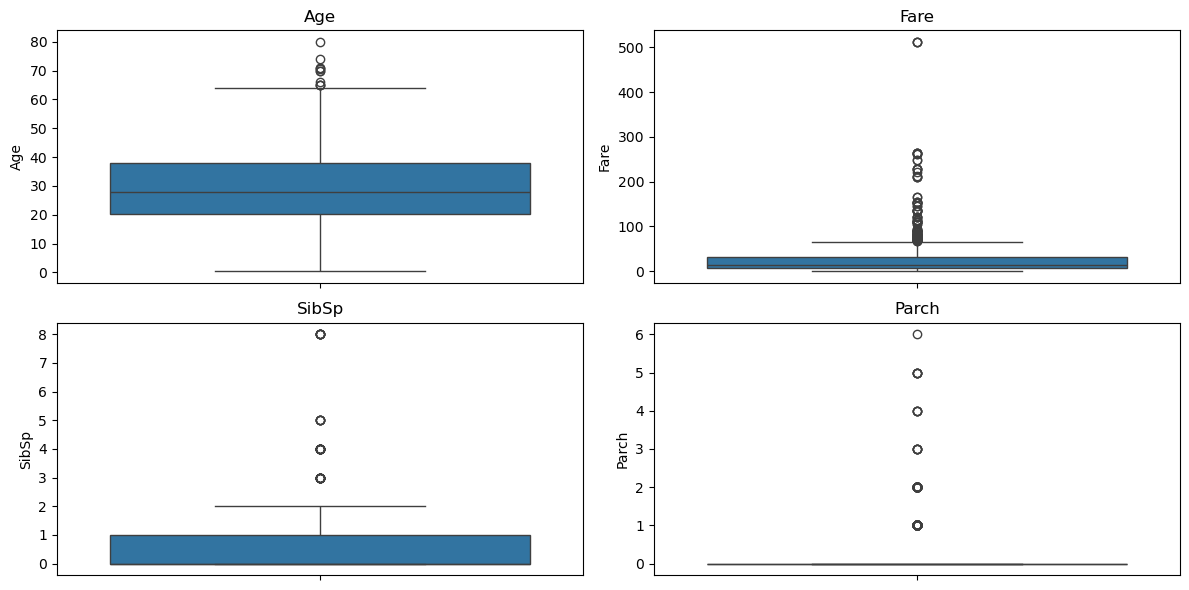

In [12]:
plt.figure(figsize=(12,6))

for i, column in enumerate(['Age','Fare','SibSp','Parch']):
    plt.subplot(2,2,i+1)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()

plt.savefig(r"C:\Users\saifia computers\Desktop\DecodeLabs_Internship\Project_01_EDA_Feature_Engineering\images\boxplots.png", dpi=300, bbox_inches="tight")

plt.show()

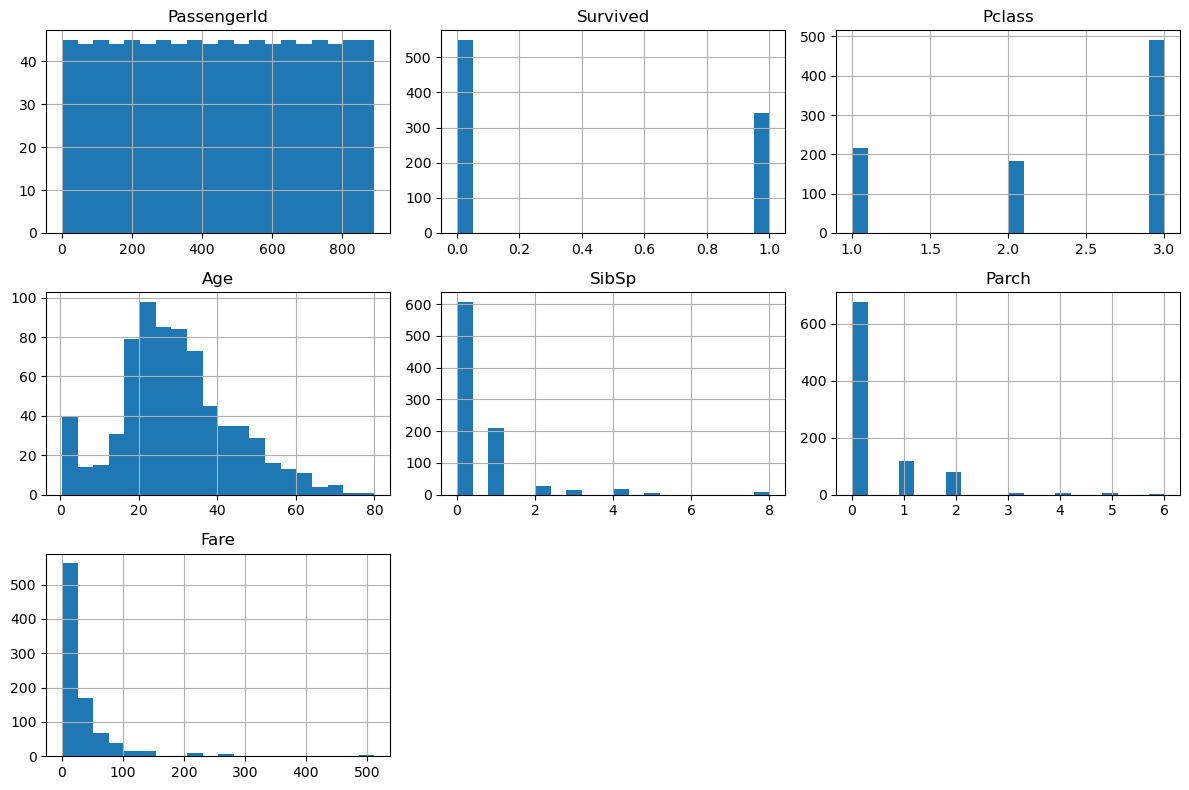

In [13]:
numerical_columns = df.select_dtypes(include=['int64', 'float64'])

numerical_columns.hist(figsize=(12,8), bins=20)

plt.tight_layout()

plt.savefig(r"C:\Users\saifia computers\Desktop\DecodeLabs_Internship\Project_01_EDA_Feature_Engineering\images\histograms.png", dpi=300, bbox_inches="tight")

plt.show()

In [14]:
df_clean = df.copy()

In [15]:
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())

In [16]:
df_clean["Age"].isnull().sum()

0

In [17]:
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

In [18]:
df_clean["Embarked"].isnull().sum()

0

In [19]:
df_clean["Cabin_Available"] = df_clean["Cabin"].notnull().astype(int)

In [20]:
df_clean[["Cabin", "Cabin_Available"]].head(10)

,Cabin,Cabin_Available
0,NaN,0
1,C85,1
2,NaN,0
3,C123,1
4,NaN,0
5,NaN,0
6,E46,1
7,NaN,0
8,NaN,0
9,NaN,0


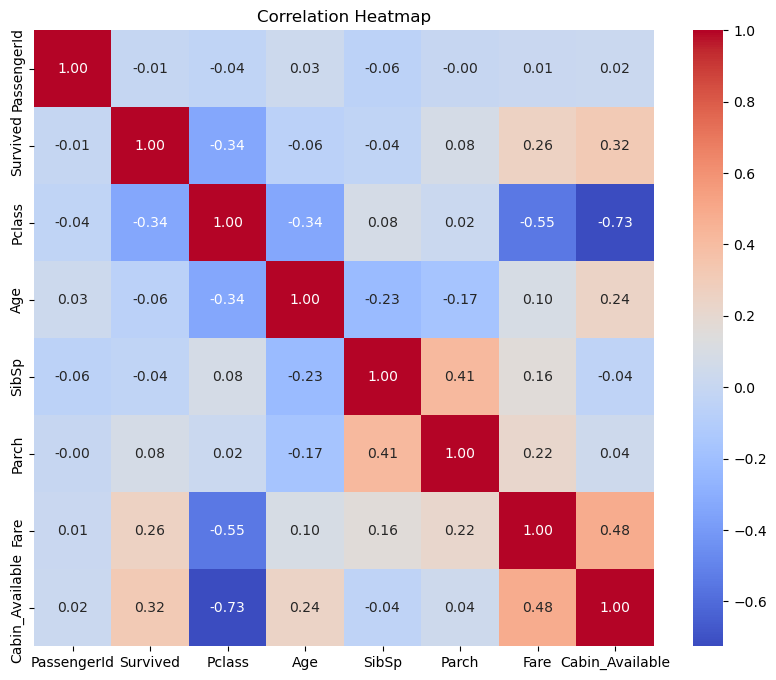

In [21]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df_clean.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig(r"C:\Users\saifia computers\Desktop\DecodeLabs_Internship\Project_01_EDA_Feature_Engineering\images\correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

In [22]:
df_clean.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin_Available
PassengerId,1.000000,-0.005007,-0.035144,0.034212,-0.057527,-0.001652,0.012658,0.019919
Survived,-0.005007,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307,0.316912
Pclass,-0.035144,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500,-0.725541
Age,0.034212,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688,0.240314
SibSp,-0.057527,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651,-0.040460
Parch,-0.001652,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225,0.036987
Fare,0.012658,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000,0.482075
Cabin_Available,0.019919,0.316912,-0.725541,0.240314,-0.040460,0.036987,0.482075,1.000000


## Observation

- Passenger Class (Pclass) has a moderate negative correlation with survival.
- Fare has a moderate positive correlation with survival.
- Cabin_Available also shows a positive relationship with survival.
- PassengerId has almost no meaningful relationship with other variables and may be removed later.
- Fare and Pclass are moderately related, which matches expectations for Titanic passengers.

In [23]:
df_clean["FamilySize"] = df_clean["SibSp"] + df_clean["Parch"] + 1

In [24]:
df_clean[["SibSp", "Parch", "FamilySize"]].head(10)

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1
5,0,0,1
6,0,0,1
7,3,1,5
8,0,2,3
9,1,0,2


In [25]:
df_clean["IsAlone"] = (df_clean["FamilySize"] == 1).astype(int)

In [26]:
df_clean[["FamilySize", "IsAlone"]].head(10)

,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1
5,1,1
6,1,1
7,5,0
8,3,0
9,2,0


In [27]:
df_clean["Title"] = df_clean["Name"].str.extract(r",\s*([^\.]+)\.")

In [28]:
df_clean[["Name", "Title"]].head(10)

,Name,Title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr
5,"Moran, Mr. James",Mr
6,"McCarthy, Mr. Timothy J",Mr
7,"Palsson, Master. Gosta Leonard",Master
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Mrs
9,"Nasser, Mrs. Nicholas (Adele Achem)",Mrs


In [29]:
df_clean["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64

## Feature Engineering

### Feature 1: FamilySize
Created by combining `SibSp` and `Parch` with the passenger.

### Feature 2: IsAlone
Indicates whether the passenger traveled alone.

### Feature 3: Title
Extracted passenger titles (Mr, Mrs, Miss, etc.) from the Name column.

In [30]:
df_clean["Title"] = df_clean["Title"].replace(
    ["Dr", "Rev", "Col", "Major", "Capt",
     "Lady", "Sir", "Don", "Jonkheer",
     "Countess", "Mme", "Mlle", "Ms"],
    "Rare"
)

In [31]:
df_clean["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Rare             26
the Countess      1
Name: count, dtype: int64

In [32]:
df_clean["Title"] = df_clean["Title"].replace(
    ["Dr", "Rev", "Col", "Major", "Capt",
     "Lady", "Sir", "Don", "Jonkheer",
     "Countess", "Mme", "Mlle", "Ms"],
    "Rare"
)

In [33]:
df_clean["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Rare             26
the Countess      1
Name: count, dtype: int64

In [34]:
df_clean = df_clean.drop(
    columns=["PassengerId", "Name", "Ticket", "Cabin"]
)

In [35]:
df_clean.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'Cabin_Available', 'FamilySize', 'IsAlone', 'Title'],
      dtype='object')

In [36]:
df_clean["Sex"] = df_clean["Sex"].map({
    "male": 0,
    "female": 1
})

In [37]:
df_clean["Sex"].value_counts()

Sex
0    577
1    314
Name: count, dtype: int64

In [38]:
df_clean["Embarked"] = df_clean["Embarked"].map({
    "S": 0,
    "C": 1,
    "Q": 2
})

In [39]:
df_clean["Embarked"].value_counts()

Embarked
0    646
1    168
2     77
Name: count, dtype: int64

In [40]:
df_clean["Title"] = df_clean["Title"].map({
    "Mr": 0,
    "Miss": 1,
    "Mrs": 2,
    "Master": 3,
    "Rare": 4
})

In [41]:
df_clean["Title"].value_counts()

Title
0.0    517
1.0    182
2.0    125
3.0     40
4.0     26
Name: count, dtype: int64

In [42]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Survived         891 non-null    int64  
 1   Pclass           891 non-null    int64  
 2   Sex              891 non-null    int64  
 3   Age              891 non-null    float64
 4   SibSp            891 non-null    int64  
 5   Parch            891 non-null    int64  
 6   Fare             891 non-null    float64
 7   Embarked         891 non-null    int64  
 8   Cabin_Available  891 non-null    int32  
 9   FamilySize       891 non-null    int64  
 10  IsAlone          891 non-null    int32  
 11  Title            890 non-null    float64
dtypes: float64(3), int32(2), int64(7)
memory usage: 76.7 KB


In [43]:
df_clean.to_csv(r"C:\Users\saifia computers\Desktop\DecodeLabs_Internship\Project_01_EDA_Feature_Engineering\output/cleaned_titanic.csv", index=False)